In [1]:
import os

In [5]:
ls

 LICENSE                     so_50kit_baseline.sh
 README.md                   so_50kit_gaussian.sh
 RS3DAda.sh                 'so_autoalbument_50k copy.sh'
 __pycache__/                so_autoalbument_50k.sh
 autoalbument/               so_autoalbument_50k_flip.sh
 compute_gsd.py              so_style_100kit.sh
 data@                       sourceonly.sh
 dataset/                    sourceonly_100kit.sh
 eval_gaussian_bashline.sh   sourceonly_10kit.sh
 eval_he.sh                  sourceonly_christian.sh
 eval_ss.sh                  stylized_so_100k.sh
 evaluation.py               stylized_src_only_0.5_100k/
 figs/                       temp.json
 index.html                  temp_cleaned.json
 infer_height.py             temp_notebook.ipynb
 infer_height.sh             temp_test.py
 infer_segmentation.py       temp_transform.json
 kubectl.sha256              train_dpt_RS3DAda.py
 kubernetes_job_defs/        train_dpt_autoalbument.py
 latest_compatible.json      train_dpt_autoalbument_f

In [179]:
import os
import torch
from torch.utils import data
from albumentations import Compose, RandomCrop, Normalize
from albumentations.pytorch import ToTensorV2
import albumentations as A
from dataset.dataset import MultiTaskDataSet
from utils.datasets_config import get_dataset_category


# =============================
#  Hardcoded debug configuration
# =============================

root_dir = "/mnt/synrs3d/SynRS3D/data"

train_set = [
    'grid_g05_mid_v2', 'grid_g005_mid_v2', 'terrain_g05_low_v1', 'terrain_g005_low_v1',
    'grid_g05_mid_v1', 'grid_g005_mid_v1', 'terrain_g05_mid_v1', 'terrain_g005_mid_v1',
    'grid_g05_low_v1', 'grid_g005_low_v1', 'grid_g05_high_v1', 'grid_g005_high_v1',
    'terrain_g05_high_v1', 'terrain_g005_high_v1',
    'terrain_g1_low_v1', 'terrain_g1_mid_v1', 'terrain_g1_high_v1'
]

images_file = ['train.txt', 'test_syn.txt', 'train.txt']
policy_path = './autoalbument/policies/only_brightness.json'
crop_size = 392
batch_size = 1
multi_task = True
combine_class = False
apply_da = []  # empty for debugging
max_da_images = 1200
stylized_p = 0.0

In [207]:
def get_autoalbument_transforms(policy_path, crop_size=392):
    """Load and configure AutoAlbument policy.
    
    Args:
        policy_path: Path to the AutoAlbument policy JSON file
        crop_size: Size for random crop
        
    Returns:
        A composed Albumentations transform
    """
    # Load the AutoAlbument policy
    policy = A.load(policy_path, data_format='json')
    # print the policy
    print(policy)
    
    # Create a list of transforms
    transforms = [
        A.RandomCrop(crop_size, crop_size),
        policy,
        # ToTensorV2()
    ]
    
    return A.Compose(transforms)

In [221]:
train_transforms_1 = get_autoalbument_transforms(policy_path, crop_size)
train_transforms_2 = get_autoalbument_transforms('./autoalbument/policies/placebo_policy.json', crop_size)

Compose([
  LongestMaxSize(p=1.0, area_for_downscale=None, interpolation=1, mask_interpolation=0, max_size=[392], max_size_hw=None),
  PadIfNeeded(p=1.0, border_mode=0, fill=0.0, fill_mask=0.0, min_height=392, min_width=392, pad_height_divisor=None, pad_width_divisor=None, padding=0, position='center'),
  OneOf([
    Sequential([
      OneOf([
        RandomBrightnessContrast(p=0.5226849913597107, brightness_by_max=True, brightness_limit=(0.14843523502349854, 0.14843523502349854), contrast_limit=(0.0, 0.0), ensure_safe_range=False),
        NoOp(p=0.4773150086402893),
      ], p=1.0),
    ], p=1.0),
  ], p=1),
  Normalize(p=1.0, max_pixel_value=1.0, mean=(123.675, 116.28, 103.53), normalization='standard', std=(58.395, 57.12, 57.375)),
  ToTensorV2(p=1.0, transpose_mask=True),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={}, is_check_shapes=True)
Compose([
  LongestMaxSize(p=1.0, area_for_downscale=None, interpolation=1, mask_interpolation=0, max_size=[392], max

/opt/conda/lib/python3.12/site-packages/albumentations/core/serialization.py:185: UserWarning: Argument(s) 'value, mask_value' are not valid for transform PadIfNeeded
  return cls(**args)


In [222]:
train_data_paths = [os.path.join(root_dir, ds) for ds in train_set]
train_dataset_type = get_dataset_category(set(train_set))

syn_dataset = MultiTaskDataSet(
    train_data_paths,
    is_training=True,
    images_file=images_file,
    transforms=train_transforms,
    max_iters=100 * batch_size,
    max_da_images=max_da_images,
    multi_task=multi_task,
    combine_class=combine_class,
    apply_da=apply_da,
    da_aug_paras={},
    tgt_root_dir=train_data_paths,
    stylized_p=stylized_p
)

syn_loader = data.DataLoader(syn_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

In [223]:
transforms_list = [
RandomCrop(392, 392),
]
transforms_list.append(Normalize(mean=(123.675, 116.28, 103.53), std=(58.395, 57.12, 57.375), max_pixel_value=1, always_apply=True))
transforms_list.append(ToTensorV2())

traning_src_transforms = Compose(transforms_list)

/tmp/ipykernel_902/2533354143.py:4: UserWarning: Argument(s) 'always_apply' are not valid for transform Normalize
  transforms_list.append(Normalize(mean=(123.675, 116.28, 103.53), std=(58.395, 57.12, 57.375), max_pixel_value=1, always_apply=True))


In [242]:
def seed_all(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [243]:
train_paths = [os.path.join(root_dir, ds) for ds in train_set]
dataset_type = get_dataset_category(set(train_set))

seed_all(42)
# Original dataset (no transforms)
dataset_orig = MultiTaskDataSet(
    train_paths,
    is_training=True,
    images_file=images_file,
    transforms=traning_src_transforms,
    max_iters=1,
    multi_task=multi_task,
    combine_class=combine_class
)
seed_all(42)
# Transformed dataset (with AutoAlbument)
dataset_trans = MultiTaskDataSet(
    train_paths,
    is_training=True,
    images_file=images_file,
    transforms=train_transforms,
    max_iters=1,
    multi_task=multi_task,
    combine_class=combine_class
)
seed_all(42)
dataset_trans_2 = MultiTaskDataSet(
    train_paths,
    is_training=True,
    images_file=images_file,
    transforms=train_transforms_2,
    max_iters=1,
    multi_task=multi_task,
    combine_class=combine_class
)


In [244]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# =============================
# Pick a random sample (same index)
# =============================
idx = 0
seed_all(42)
sample_orig = dataset_orig[idx]
seed_all(42)
sample_trans = dataset_trans[idx]
seed_all(42)
sample_trans2 = dataset_trans_2[idx]

img_orig = sample_orig['image']
mask_orig = sample_orig.get('ss_mask', None)

img_trans = sample_trans['image']
mask_trans = sample_trans.get('ss_mask', None)

img_trans2 = sample_trans2['image']
mask_trans2 = sample_trans2.get('ss_mask', None)

print(f"\nSample #{idx}")
print(f"Original image shape: {img_orig.shape}")
print(f"Transformed1 image shape: {img_trans.shape}")
print(f"Transformed2 image shape: {img_trans2.shape}")


Sample #0
Original image shape: torch.Size([3, 392, 392])
Transformed1 image shape: torch.Size([3, 392, 392])
Transformed2 image shape: torch.Size([3, 392, 392])


In [245]:
img_orig.shape, img_trans.shape, mask_orig.shape, mask_trans.shape

(torch.Size([3, 392, 392]),
 torch.Size([3, 392, 392]),
 torch.Size([1, 392, 392]),
 torch.Size([392, 1, 392]))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.7336819].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.8556863].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.6988235].


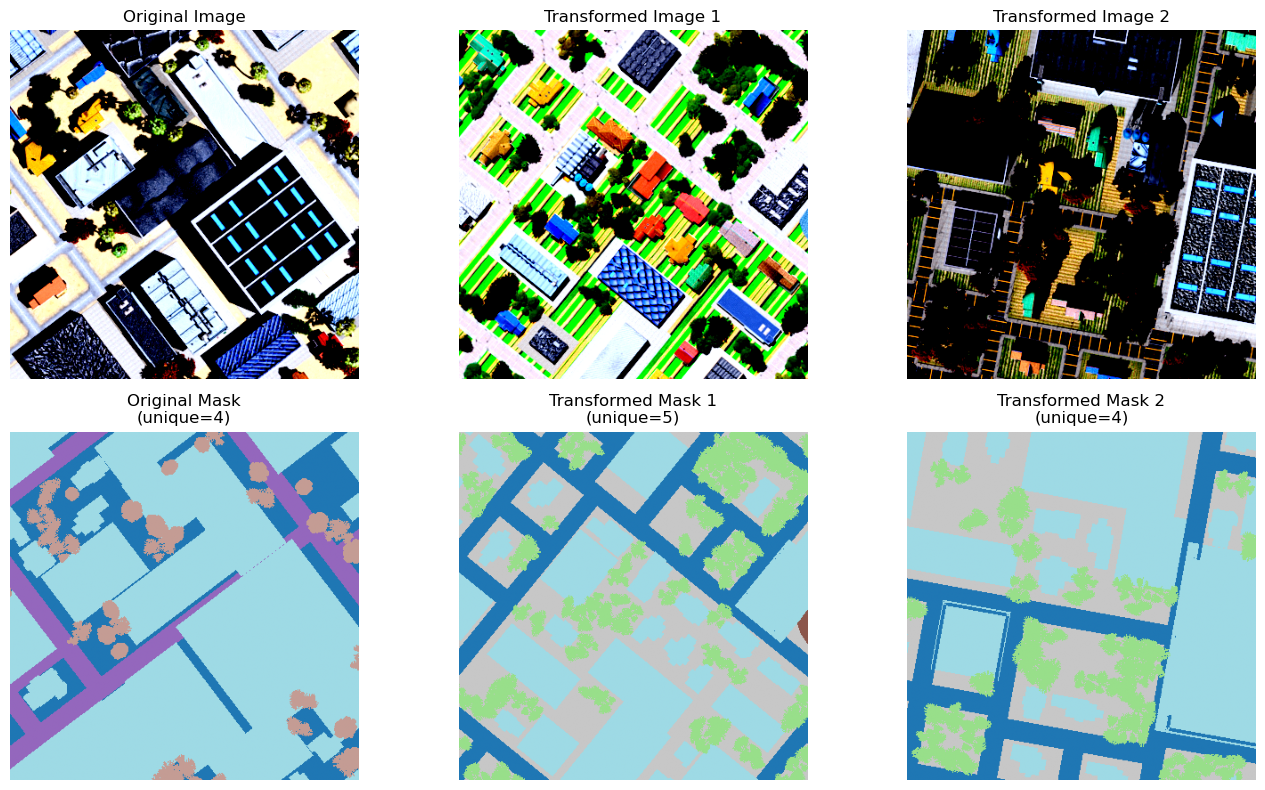

In [246]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0, 0].imshow(img_orig.permute(1, 2, 0))
axes[0, 0].set_title("Original Image")
axes[0, 1].imshow(img_trans.permute(1, 2, 0))
axes[0, 1].set_title("Transformed Image 1")
axes[0, 2].imshow(img_trans2.permute(1, 2, 0))
axes[0, 2].set_title("Transformed Image 2")

if mask_orig is not None:
    axes[1, 0].imshow(mask_orig.permute(1, 2, 0), cmap='tab20')
    axes[1, 0].set_title(f"Original Mask\n(unique={len(np.unique(mask_orig))})")

if mask_trans is not None:
    axes[1, 1].imshow(mask_trans.permute(2, 0, 1), cmap='tab20')
    axes[1, 1].set_title(f"Transformed Mask 1\n(unique={len(np.unique(mask_trans))})")

if mask_trans2 is not None:
    axes[1, 2].imshow(mask_trans2.permute(2, 0, 1), cmap='tab20')
    axes[1, 2].set_title(f"Transformed Mask 2\n(unique={len(np.unique(mask_trans2))})")

for ax in axes.ravel():
    ax.axis('off')

plt.tight_layout()
plt.show()

In [251]:
from torch.utils.data import DataLoader

loader_orig = DataLoader(
    dataset_orig,
    batch_size=1,
    shuffle=False,
    num_workers=1,
    pin_memory=True,
    drop_last=False,
)

loader_trans = DataLoader(
    dataset_trans,
    batch_size=1,
    shuffle=False,
    num_workers=1,
    pin_memory=True,
    drop_last=False,
)

loader_trans2 = DataLoader(
    dataset_trans_2,
    batch_size=1,
    shuffle=False,
    num_workers=1,
    pin_memory=True,
    drop_last=False,
)

In [254]:
SEED = 3

seed_all(SEED)
batch_orig = next(iter(loader_orig))

seed_all(SEED)
batch_trans = next(iter(loader_trans))

seed_all(SEED)
batch_trans2 = next(iter(loader_trans2))

In [255]:
mg_orig = batch_orig['image'][0]
mask_orig = batch_orig.get('ss_mask', None)
mask_orig = mask_orig[0] if mask_orig is not None else None

img_trans = batch_trans['image'][0]
mask_trans = batch_trans.get('ss_mask', None)
mask_trans = mask_trans[0] if mask_trans is not None else None

img_trans2 = batch_trans2['image'][0]
mask_trans2 = batch_trans2.get('ss_mask', None)
mask_trans2 = mask_trans2[0] if mask_trans2 is not None else None

In [261]:
print(f"\nBatched sample inspection:")
print(f"  Original image shape: {img_orig.shape}")
print(f"  Transformed 1 image shape: {img_trans.shape}")
print(f"  Transformed 2 image shape: {img_trans2.shape}")

print(f'mask_orig.shape: {mask_orig.shape}')
print(f'mask_trans1.shape: {mask_trans.shape}')
print(f'mask_trans2.shape: {mask_trans2.shape}')


Batched sample inspection:
  Original image shape: torch.Size([3, 392, 392])
  Transformed 1 image shape: torch.Size([3, 392, 392])
  Transformed 2 image shape: torch.Size([3, 392, 392])
mask_orig.shape: torch.Size([1, 392, 392])
mask_trans1.shape: torch.Size([392, 1, 392])
mask_trans2.shape: torch.Size([392, 1, 392])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.7336819].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.115362..-1.7870152].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.6988235].


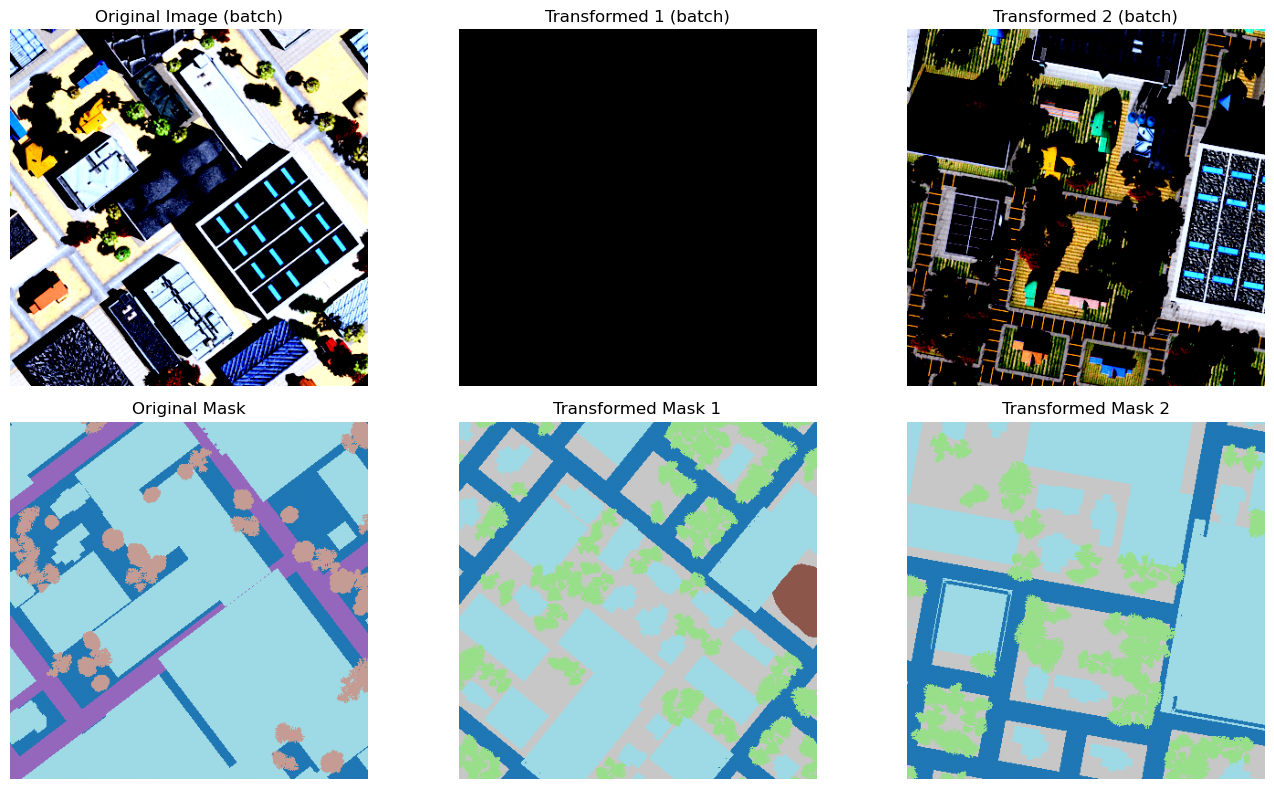

In [258]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0, 0].imshow(img_orig.permute(1, 2, 0))
axes[0, 0].set_title("Original Image (batch)")

axes[0, 1].imshow(img_trans.permute(1, 2, 0))
axes[0, 1].set_title("Transformed 1 (batch)")

axes[0, 2].imshow(img_trans2.permute(1, 2, 0))
axes[0, 2].set_title("Transformed 2 (batch)")

if mask_orig is not None:
    axes[1, 0].imshow(mask_orig.permute(1, 2, 0), cmap='tab20')
    axes[1, 0].set_title("Original Mask")

if mask_trans is not None:
    axes[1, 1].imshow(mask_trans.permute(2, 0, 1), cmap='tab20')
    axes[1, 1].set_title("Transformed Mask 1")

if mask_trans2 is not None:
    axes[1, 2].imshow(mask_trans2.permute(2, 0, 1), cmap='tab20')
    axes[1, 2].set_title("Transformed Mask 2")

for ax in axes.ravel():
    ax.axis('off')

plt.tight_layout()
plt.show()